In [ ]:
!pip install easyocr

print("✅ EasyOCR installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 22.1 MB/s eta 0:00:00
✅ EasyOCR installed.


# Import Modules

In [ ]:
import easyocr
import numpy as np
from PIL import Image, ImageFilter, ImageOps, ImageEnhance
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import display
import os
import matplotlib.pyplot as plt

print("✅ Modules imported.")

✅ Modules imported.


# Initialize EasyOCR Reader

In [ ]:
# We create the reader once and reuse it for all images.
# 'en' is for English. You can add other languages if needed.
reader = easyocr.Reader(['en'])  # This downloads the model on first run
print("✅ EasyOCR reader created.")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ EasyOCR reader created.


# Define Transformation Functions

In [ ]:
# All functions take a PIL Image and return a transformed PIL Image.

def rotate_image(img, angle=5):
    """Rotate image by given angle (degrees)."""
    return img.rotate(angle, expand=True, fillcolor=(255,255,255))

def skew_image(img, shear=0.2):
    """Apply horizontal shear (skew)."""
    arr = np.array(img)
    h, w = arr.shape[:2]
    M = np.float32([[1, shear, 0], [0, 1, 0]])
    new_w = int(w + abs(shear) * h)
    sheared = cv2.warpAffine(arr, M, (new_w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(sheared)

def blur_image(img, radius=2):
    """Apply Gaussian blur."""
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def add_noise(img, intensity=25):
    """Add random Gaussian noise."""
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, intensity, arr.shape)
    noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def adjust_brightness(img, factor=1.5):
    """Change brightness (factor >1 brighter, <1 darker)."""
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(factor)

def adjust_contrast(img, factor=1.5):
    """Change contrast."""
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(factor)

def resize_image(img, scale=0.7):
    """Resize image (scale <1 smaller, >1 larger)."""
    new_size = (int(img.width * scale), int(img.height * scale))
    return img.resize(new_size, Image.Resampling.LANCZOS)

def invert_colors(img):
    """Invert image colors."""
    return ImageOps.invert(img.convert('RGB'))

def perspective_warp(img, strength=0.05):
    """
    Apply a weak perspective distortion.
    """
    w, h = img.size
    src = np.float32([[0,0], [w-1,0], [0,h-1], [w-1,h-1]])
    dst = src + strength * np.random.uniform(-h, h, src.shape)
    dst = dst.astype(np.float32)
    matrix = cv2.getPerspectiveTransform(src, dst)
    arr = np.array(img)
    warped = cv2.warpPerspective(arr, matrix, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(warped)

# Load Your Image

✅ Image found at /content/Text_image.webp
📸 Original Image:


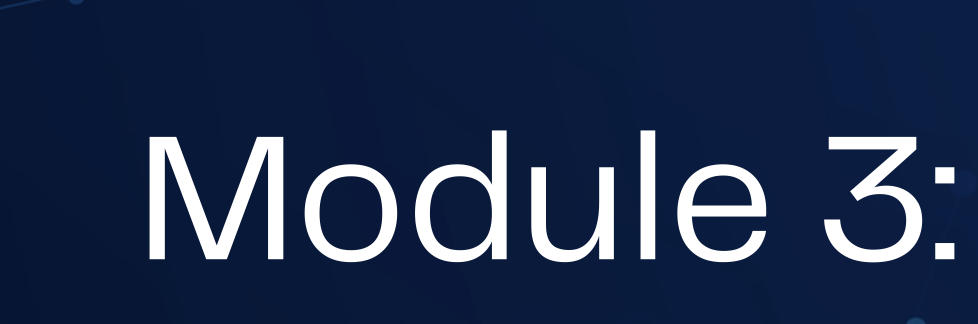

In [ ]:
image_path = '/content/Text_image.webp'   # <-- CHANGE THIS TO YOUR IMAGE PATH

if not os.path.exists(image_path):
    print(f"❌ Image not found at {image_path}. Please upload your image and update the path.")
    from google.colab import files
    print("Upload your image now:")
    uploaded = files.upload()
    for fn in uploaded.keys():
        image_path = f"/content/{fn}"
        print(f"✅ Using uploaded file: {image_path}")
        break
else:
    print(f"✅ Image found at {image_path}")

# Load the original image
original_img = Image.open(image_path).convert('RGB')
print("📸 Original Image:")
display(original_img)

# Generate Variations

In [ ]:
variations = []

# Always keep the original as first
variations.append((original_img, "Original"))

# Add variations (you can add/remove or change parameters)
variations.append((rotate_image(original_img, 5), "Rotated +5°"))
variations.append((rotate_image(original_img, -5), "Rotated -5°"))
variations.append((rotate_image(original_img, 15), "Rotated +15°"))
variations.append((skew_image(original_img, 0.2), "Skewed (shear)"))
variations.append((blur_image(original_img, 2), "Blurred"))
variations.append((add_noise(original_img, 30), "With Noise"))
variations.append((adjust_brightness(original_img, 1.8), "Brighter"))
variations.append((adjust_brightness(original_img, 0.5), "Darker"))
variations.append((adjust_contrast(original_img, 2.0), "High Contrast"))
variations.append((resize_image(original_img, 0.5), "Resized 50%"))
variations.append((invert_colors(original_img), "Inverted Colors"))
variations.append((perspective_warp(original_img, 0.03), "Perspective Warp"))

print(f"✅ Created {len(variations)} image variations.")

✅ Created 13 image variations.


# Run EasyOCR on Each Variation and Display


OCR RESULTS ON IMAGE VARIATIONS (EasyOCR)


--- Variation 1: Original ---


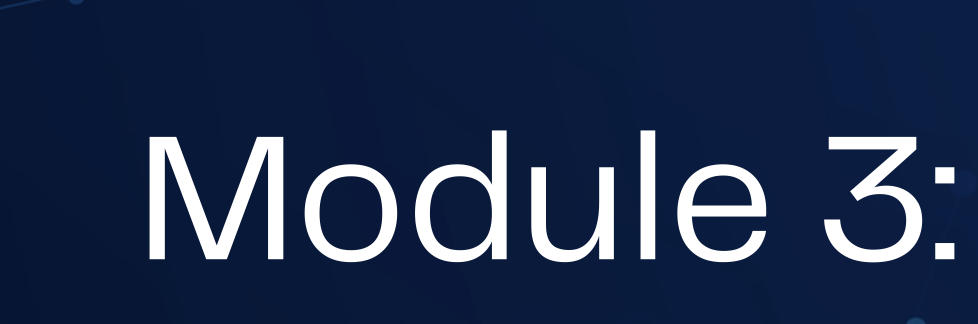

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 2: Rotated +5° ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


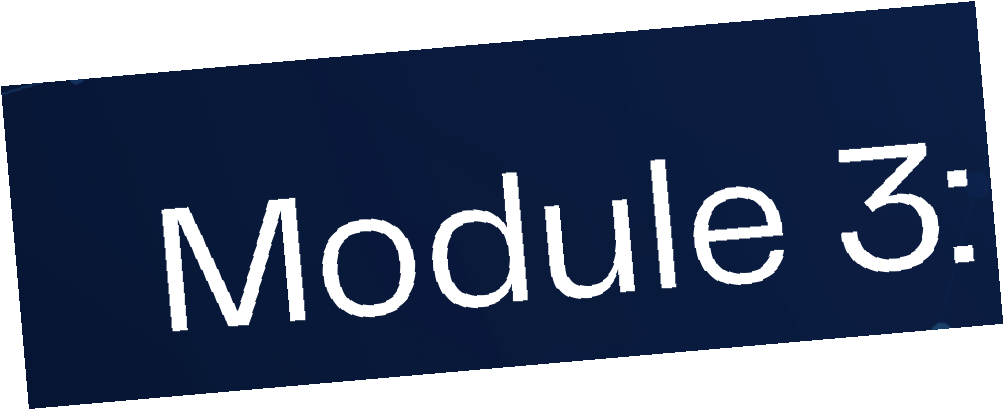

📝 Extracted text: Module 31
----------------------------------------

--- Variation 3: Rotated -5° ---


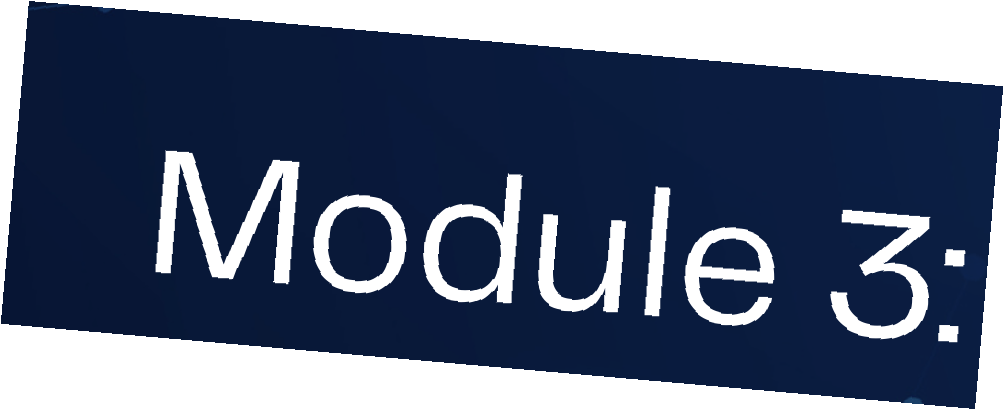

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 4: Rotated +15° ---


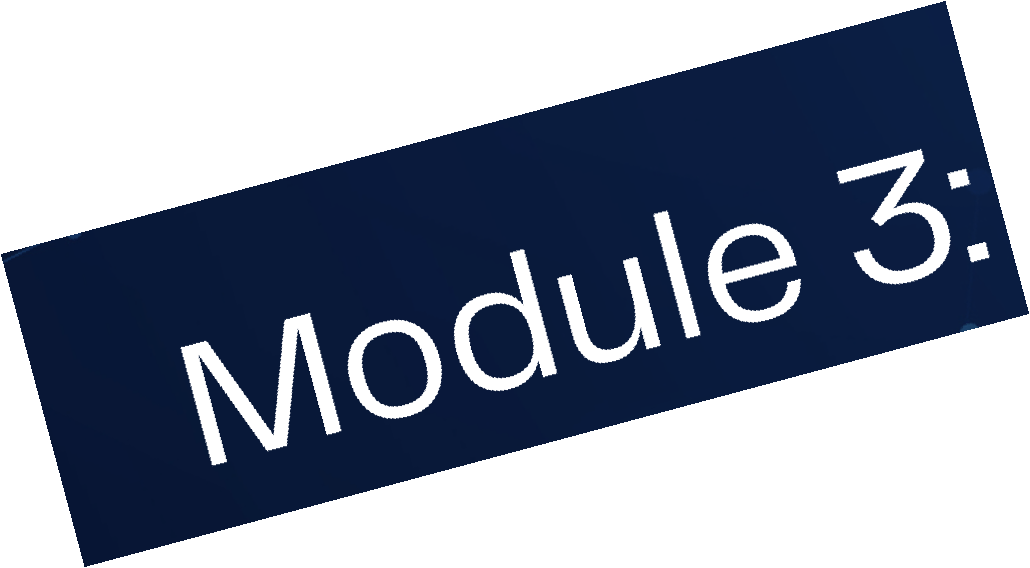

📝 Extracted text: 3. Module
----------------------------------------

--- Variation 5: Skewed (shear) ---


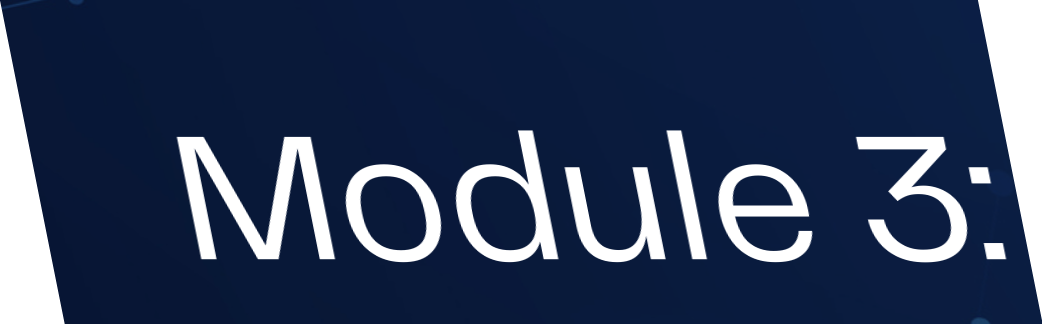

📝 Extracted text: Module 31
----------------------------------------

--- Variation 6: Blurred ---


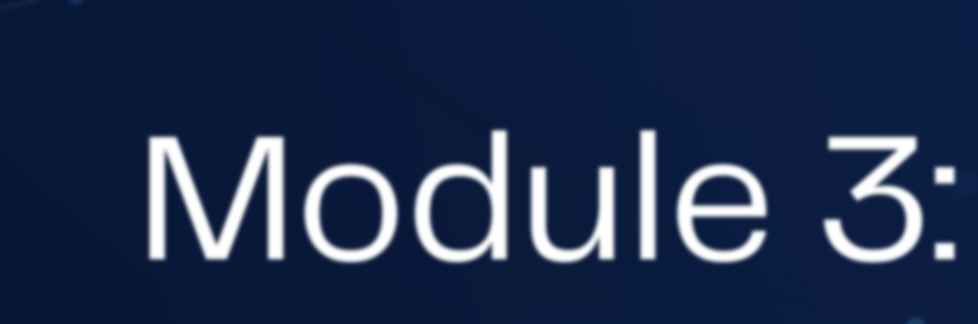

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 7: With Noise ---


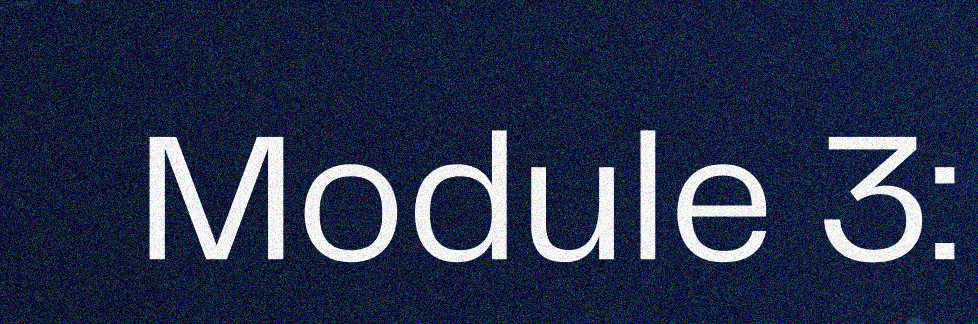

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 8: Brighter ---


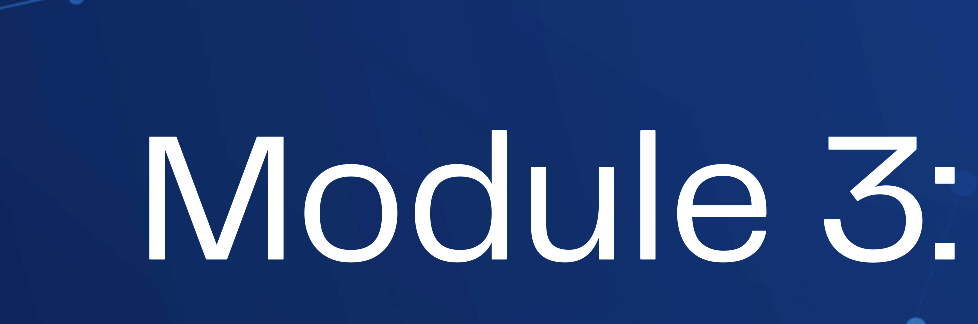

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 9: Darker ---


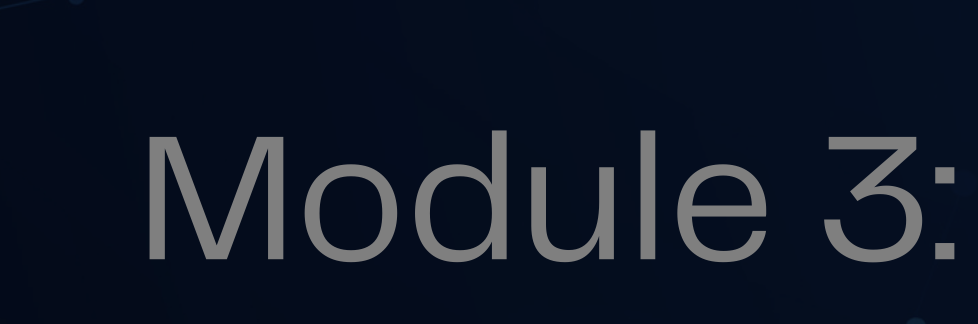

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 10: High Contrast ---


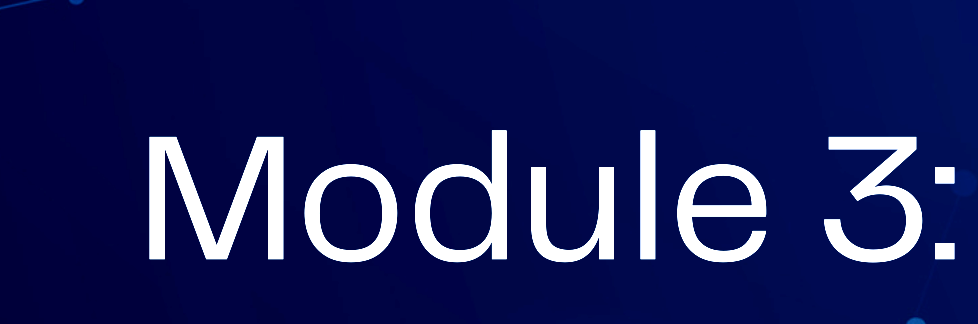

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 11: Resized 50% ---


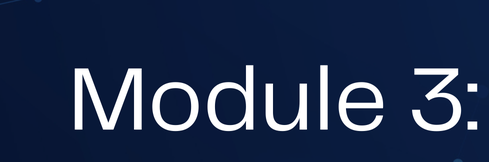

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 12: Inverted Colors ---


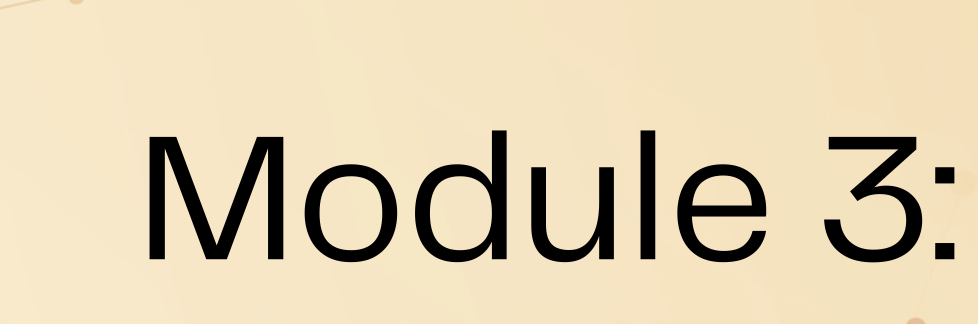

📝 Extracted text: Module 3:
----------------------------------------

--- Variation 13: Perspective Warp ---


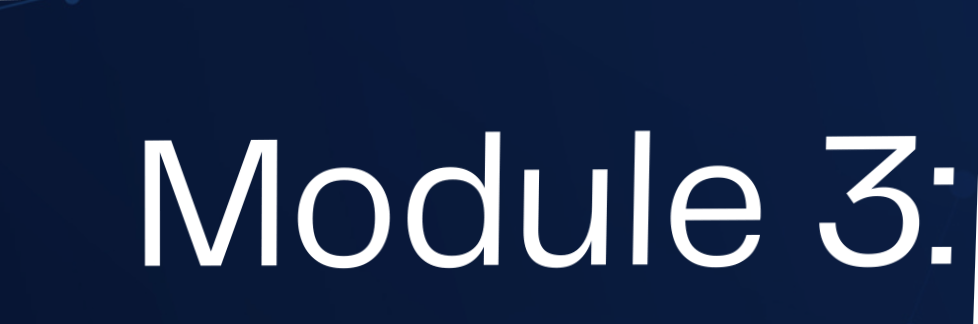

📝 Extracted text: Module 3:
----------------------------------------

✅ Done.


In [ ]:
print("\n" + "="*70)
print("OCR RESULTS ON IMAGE VARIATIONS (EasyOCR)")
print("="*70 + "\n")

for idx, (img, desc) in enumerate(variations, 1):
    print(f"\n--- Variation {idx}: {desc} ---")

    # Display image
    display(img)

    # Convert PIL image to numpy array (EasyOCR expects numpy array or path)
    img_np = np.array(img)

    # Run EasyOCR
    try:
        results = reader.readtext(img_np)
        if results:
            # Extract text from all detections
            texts = [item[1] for item in results]
            extracted = ' '.join(texts)
            print(f"📝 Extracted text: {extracted}")
            # Optionally show confidence
            # for bbox, text, conf in results:
            #     print(f"   {text} (confidence: {conf:.2f})")
        else:
            print("📝 No text detected")
    except Exception as e:
        print(f"❌ OCR failed: {e}")

    print("-" * 40)

print("\n✅ Done.")